# Updraft Helicity Tracks
Ty Janoski

## Setup

In [10]:
# Import statements
from typing import List

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import scienceplots  # noqa: F401
import scipy.stats as stats
import xarray as xr
from scipy.ndimage import label
from scipy.stats import mannwhitneyu, ttest_ind

plt.style.use(["science", "nature"])
plt.rcParams["text.usetex"] = True


In [4]:
def get_wofs_all(init: int) -> xr.Dataset:
    """Read in WoFS output based on initialization time."""
    file_pattern = f"/mnt/drive2/new-wofs/{init:02d}Z/wofs_ALL*.nc"
    loaded = xr.open_mfdataset(
        file_pattern, combine="nested", concat_dim="time", chunks="auto"
    )

    if init < 6:
        start_time = f"2021-09-02 {init:02d}:00:00"
        end_time = f"2021-09-02 {init + 6:02d}:00:00"
    else:
        start_time = f"2021-09-01 {init:02d}:00:00"
        end_time = f"2021-09-02 {init - 24 + 6:02d}:00:00"

    loaded["time"] = xr.cftime_range(start_time, end_time, freq="5min")
    return loaded

def get_total_field(
    wofs_list: List[xr.Dataset],
    varname: str,
    start_time: str,
    end_time: str,
    init_dim: xr.DataArray,
) -> xr.DataArray:
    """
    Calculate the sum of a field (varname) for a given time slice across multiple datasets.

    Parameters:
    wofs_list (List[xr.Dataset]): List of xarray datasets.
    varname (str): Name of the variable from the Dataset to get.
    start_time (str): Start time for the time slice (format: 'YYYY-MM-DD HH:MM:SS').
    end_time (str): End time for the time slice (format: 'YYYY-MM-DD HH:MM:SS').
    init_dim (str): Name of the dimension to concatenate along.

    Returns:
    xr.DataArray: Summed-up variable concatenated along the specified dimension.
    """
    return xr.concat(
        [
            w[varname].sel(time=slice(start_time, end_time)).sum(dim="time")
            for w in wofs_list
        ],
        dim=init_dim,
    ).chunk({"init": -1})


def get_field(
    wofs_list: List[xr.Dataset],
    varname: str,
    start_time: str,
    end_time: str,
    init_dim: xr.DataArray,
) -> xr.DataArray:
    """
    Return a field (varname) for a given time slice across multiple datasets.

    Parameters:
    wofs_list (List[xr.Dataset]): List of xarray datasets.
    varname (str): Name of the variable from the Dataset to get.
    start_time (str): Start time for the time slice (format: 'YYYY-MM-DD HH:MM:SS').
    end_time (str): End time for the time slice (format: 'YYYY-MM-DD HH:MM:SS').
    init_dim (str): Name of the dimension to concatenate along.

    Returns:
    xr.DataArray: Summed-up variable concatenated along the specified dimension.
    """
    return xr.concat(
        [w[varname].sel(time=slice(start_time, end_time)) for w in wofs_list],
        dim=init_dim,
    ).chunk({"init": -1})


In [5]:
# Load in 20-23Z initializations
wofs_all = [get_wofs_all(i) for i in [20,21,22,23]]

# Define variables and parameters
lat = wofs_all[0].xlat.isel(time=0).squeeze().drop_vars("time")
lon = wofs_all[0].xlon.isel(time=0).squeeze().drop_vars("time")

# Set up Cartopy projection
proj = ccrs.LambertConformal(
    central_longitude=wofs_all[0].attrs["CEN_LON"],
    central_latitude=wofs_all[0].attrs["CEN_LAT"],
    standard_parallels=(30, 60),
)  # WoFS projection

# Create a DataArray for the initialization dimension
init = xr.DataArray(data=["20Z", "21Z", "22Z", "23Z"], dims="init").assign_coords(
    {"init": ["20Z", "21Z", "22Z", "23Z"]}
)

/tmp/ipykernel_1017129/238227043.py:15: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  loaded["time"] = xr.cftime_range(start_time, end_time, freq="5min")
/tmp/ipykernel_1017129/238227043.py:15: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  loaded["time"] = xr.cftime_range(start_time, end_time, freq="5min")
/tmp/ipykernel_1017129/238227043.py:15: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  loaded["time"] = xr.cftime_range(start_time, end_time, freq="5min")
/tmp/ipykernel_1017129/238227043.py:15: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  loaded["time"] = xr.cftime_range(start_time, end_time, freq="5min")


In [6]:
# Get the 01 to 02 UTC rainfall
rain12 = get_total_field(
    wofs_all, "rain", "2021-09-02 01:05:00", "2021-09-02 02:00:00", init_dim=init
)

# Calculate standard deviation of rainfall
std = rain12.std(dim=("init", "ne"))

# Lastly, make our area of interest where sd > 65% of max sd
aoi = std > (std.max() * 0.65)

rain12_aoi = rain12.where(aoi).mean(dim=("lat", "lon"), skipna=True)


In [7]:
# Get the indices of the wettest and driest ensemble members
ne_wet = [
    r.ne.where(r > r.quantile(0.75, dim="ne")).dropna(dim="ne").drop_vars("quantile")
    for r in rain12_aoi
]
ne_dry = [
    r.ne.where(r < r.quantile(0.25, dim="ne")).dropna(dim="ne").drop_vars("quantile")
    for r in rain12_aoi
]

wofs_wet = [wofs_all[i].sel(ne=ne_wet[i].astype(int)) for i in range(len(wofs_all))]
wofs_dry = [wofs_all[i].sel(ne=ne_dry[i].astype(int)) for i in range(len(wofs_all))]

## Plotting

In [8]:
# Extract updraft helicity
uh_wet = get_field(
    wofs_wet, "uh_0to2", "2021-09-01 23:05:00", "2021-09-02 02:00:00", init
).stack(run=("init", "ne"))
uh_dry = get_field(
    wofs_dry, "uh_0to2", "2021-09-01 23:05:00", "2021-09-02 02:00:00", init
).stack(run=("init", "ne"))

Subplot a: 70 tracks
Subplot b: 75 tracks
Subplot c: 84 tracks
Subplot d: 52 tracks
Subplot e: 52 tracks
Subplot f: 64 tracks


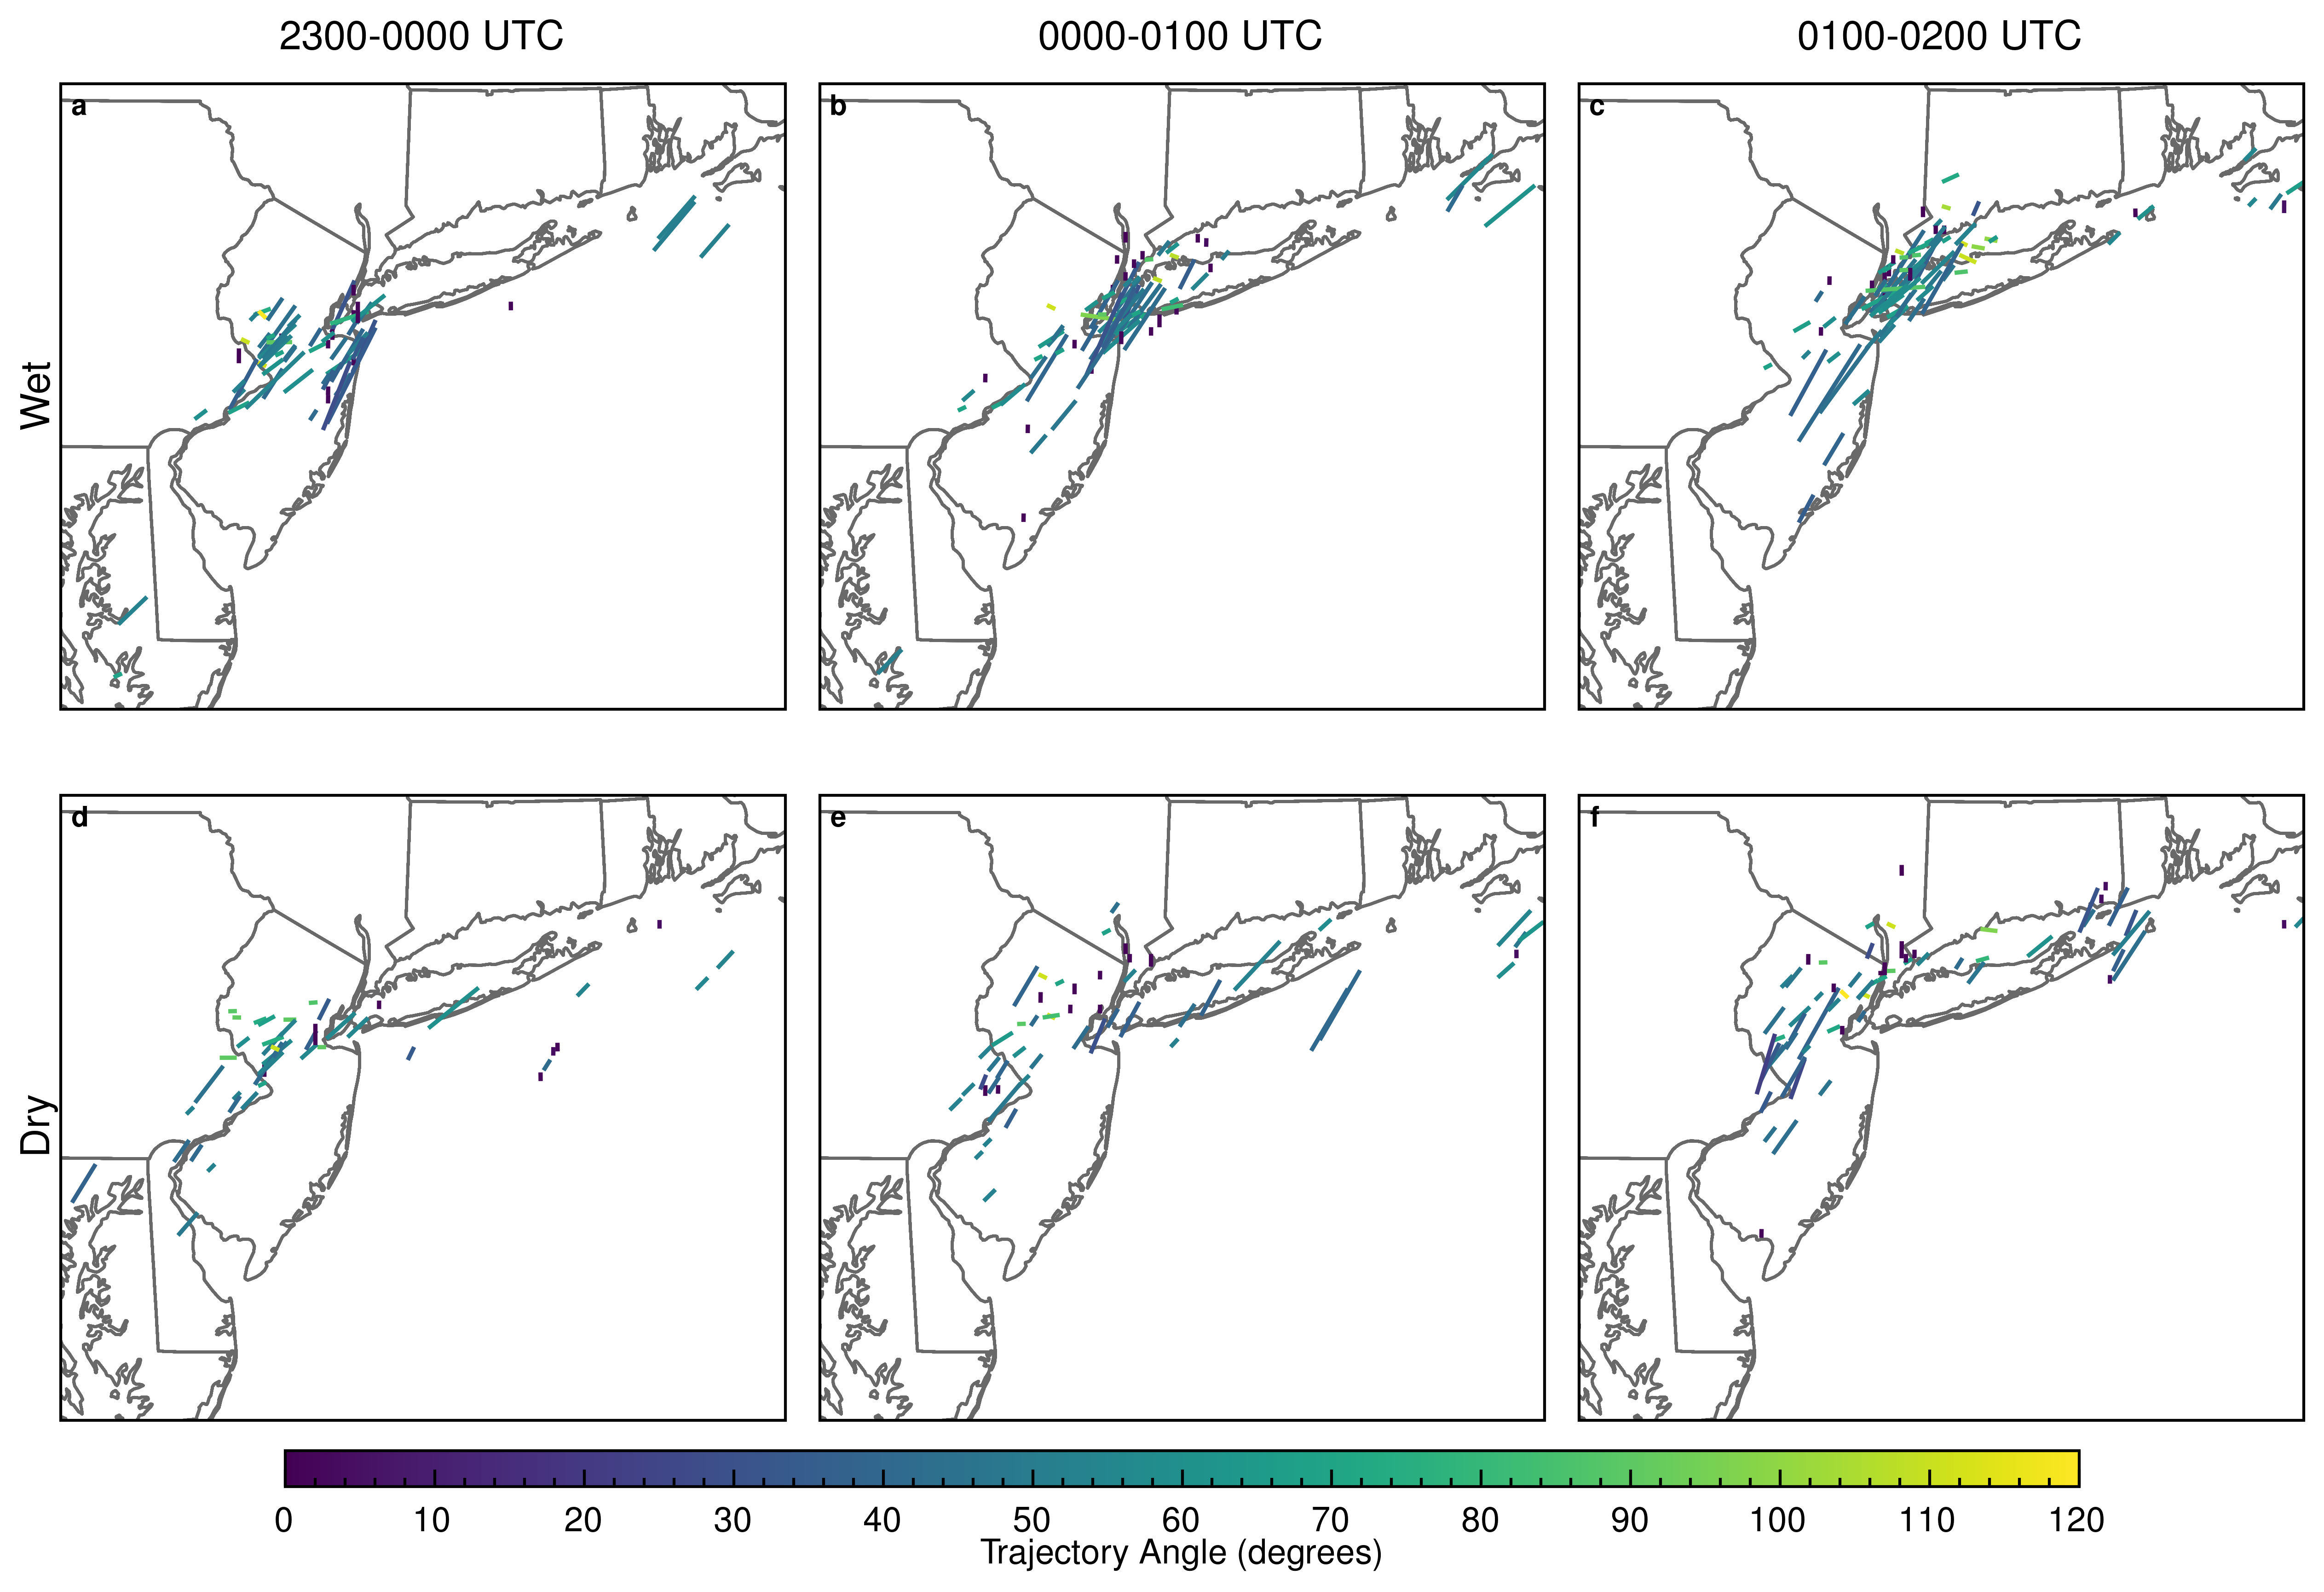

In [12]:
# Set cmap
cmap = plt.get_cmap("viridis")

# Normalize the angle values to be between 0 and 120 for the colormap
norm = mcolors.Normalize(vmin=0, vmax=120)

starts = ["2021-09-01 23:05", "2021-09-02 00:05", "2021-09-02 01:05"]
ends = ["2021-09-02 00:00", "2021-09-02 01:00", "2021-09-02 02:00"]
column_titles = ["2300-0000 UTC", "0000-0100 UTC", "0100-0200 UTC"]
letters = ["a", "b", "c", "d", "e", "f"]

data = []
for s, e in zip(starts, ends):
    data.append(uh_wet.sel(time=slice(s, e)).max(dim="time"))
for s, e in zip(starts, ends):
    data.append(uh_dry.sel(time=slice(s, e)).max(dim="time"))

# Create figure and subplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(5.5, 3.8),
    dpi=900,
    layout="constrained",
    subplot_kw=dict(projection=proj),
)

wet_angles_by_time = [[] for _ in range(3)]  # One list per wet panel
dry_angles_by_time = [[] for _ in range(3)]  # One list per dry panel


for i, ax in enumerate(axes.flat):
    if i <= 2:
        ax.set_title(column_titles[i], fontsize=7)
    track_count = 0
    for j in range(len(data[i].run)):
        # Find where UH exceeds threshold
        mask = data[i].isel(run=j) > 20

        # Label continuous blobs in the mask
        labeled_array, num_features = label(mask)

        # Iterate over each blob
        for blob in range(1, num_features + 1):
            # Find the indices of the current blob
            blob_mask = labeled_array == blob
            uh_points = np.column_stack(
                np.where(blob_mask)
            )  # Get lat/lon indices of UH > 20 for this blob

            # Exclude any blobs that are only one grid box big
            if uh_points.shape[0] > 1:
                # Convert indices to lat/lon using the mask, accessing values from xarray
                lats = lat.values[uh_points[:, 0], uh_points[:, 1]]
                lons = lon.values[uh_points[:, 0], uh_points[:, 1]]

                # Skip the regression if all x (lon) values are identical
                if np.amax(lons) != np.amin(lons):
                    # Fit a line to the lons and lats (simplified storm trajectory)
                    slope, intercept, _, _, _ = stats.linregress(lons, lats)

                    # Create line based on the slope and intercept (straight line)
                    line_lons = np.array([lons.min(), lons.max()])
                    line_lats = slope * line_lons + intercept

                    # Calculate the angle from the slope using arctan
                    angle_deg = np.degrees(np.arctan(slope))

                    # Adjust angles for negative slopes to fit the range [90, 180]
                    if angle_deg < 0:
                        angle_deg = 180 - (
                            90 + angle_deg
                        )  # Ensure angle is within the [90, 180] range
                    # Adjust positive angles so that 0 is north
                    elif angle_deg > 0:
                        angle_deg = 90 - angle_deg

                    # Get color from the colormap based on the angle
                    color = cmap(norm(angle_deg))

                    if i < 3:
                        wet_angles_by_time[i].append(angle_deg)
                    else:
                        dry_angles_by_time[i - 3].append(angle_deg)


                    track_count += 1
                    # Plot the fitted line as an estimate of storm trajectory
                    ax.plot(
                        line_lons,
                        line_lats,
                        transform=ccrs.PlateCarree(),
                        color=color,
                        linewidth=0.75,
                    )

        # Add state borders for each subplot
        ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="dimgray")

    # Set title and map extent
    ax.set_extent([-76.5, -70.5, 38, 42])

    ax.text(
        0.015, 0.95, r"\textbf{" + letters[i] + "}", transform=ax.transAxes, fontsize=5
    )
    print(f"Subplot {letters[i]}: {track_count} tracks")

# Add a colorbar to show the angle values (0 to 120 degrees)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    pad=0.02,
    aspect=50,
    shrink=0.8,
)

fig.text(-0.01, 0.74, "Wet", rotation=90, fontsize=7)
fig.text(-0.01, 0.28, "Dry", rotation=90, fontsize=7)

cb.ax.tick_params(labelsize=6)
cb.set_ticks(np.arange(0,130,10))
cb.set_label(r"Trajectory Angle (degrees)", fontsize=6, labelpad=0.01)

plt.savefig("figures/Fig12_uh_tracks.pdf", bbox_inches="tight")
plt.show()


In [13]:
from scipy.stats import ttest_ind, mannwhitneyu

for t in range(3):
    wet_angles = wet_angles_by_time[t]
    dry_angles = dry_angles_by_time[t]

    print(f"--- {column_titles[t]} ---")
    print(f"Wet angles (n={len(wet_angles)}): {wet_angles}")
    print(f"Dry angles (n={len(dry_angles)}): {dry_angles}")

    if len(wet_angles) > 1 and len(dry_angles) > 1:
        # Use Mann-Whitney U if you're unsure about normality
        u_stat, p_val = mannwhitneyu(wet_angles, dry_angles, alternative='two-sided')
        print(f"Mann-Whitney U test p-value: {p_val:.4f}")

        # Or also do a t-test if you assume normality
        t_stat, p_val_t = ttest_ind(wet_angles, dry_angles, equal_var=False)
        print(f"T-test p-value: {p_val_t:.4f}")
    print()


--- 2300-0000 UTC ---
Wet angles (n=70): [np.float64(31.54240631012545), np.float64(2.045408488887233), np.float64(1.9749340108819666), np.float64(67.93210043758978), np.float64(111.39981013208222), np.float64(39.83899374257435), np.float64(59.412141575510915), np.float64(43.806188548979314), np.float64(69.58188368950093), np.float64(68.7907738657772), np.float64(1.3478872801985915), np.float64(51.975838317053594), np.float64(52.683167570848674), np.float64(52.883139316729725), np.float64(77.26050792702053), np.float64(35.678197519719504), np.float64(46.15794007840091), np.float64(38.826132616157466), np.float64(2.045408488887233), np.float64(110.35496118493387), np.float64(1.3478872801985915), np.float64(51.94960847187466), np.float64(45.1310212473021), np.float64(59.71352109017325), np.float64(52.73224801244509), np.float64(45.60518540853199), np.float64(69.24089564365796), np.float64(63.65872182120039), np.float64(39.58153715606942), np.float64(60.68836143507279), np.float64(31.2329